### Predictive Models 
### Linear Regression 

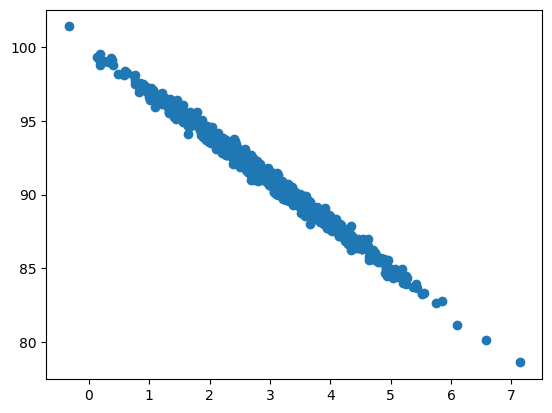

In [37]:
import numpy as np 
import matplotlib.pyplot as plt 

#Gera dados aleatórios 
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = 100 - (pageSpeeds + np.random.normal(0, 0.1, 1000)) * 3

plt.scatter(pageSpeeds, purchaseAmount) #gráfico de dispersão sobre os dados 

In [40]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(pageSpeeds, purchaseAmount)

In [41]:
r_value ** 2

np.float64(0.991112506951506)

<function matplotlib.pyplot.show(close=None, block=None)>

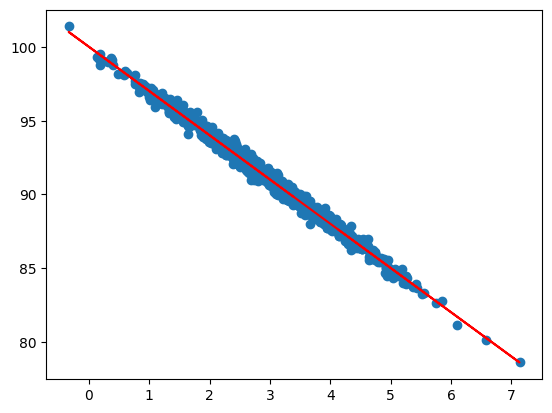

In [42]:
import matplotlib.pyplot as plt 

#cria uma função para desenhar a linha vermelha no gráfico 
def predict(x):
    return slope * x + intercept
    
fitLine = predict(pageSpeeds) #cria uma linha de ajustes com os dados 

plt.scatter(pageSpeeds, purchaseAmount)
plt.plot(pageSpeeds, fitLine, c='r')
plt.show #cria o gráfico com os dados brutos 

### Polynomial Regression 

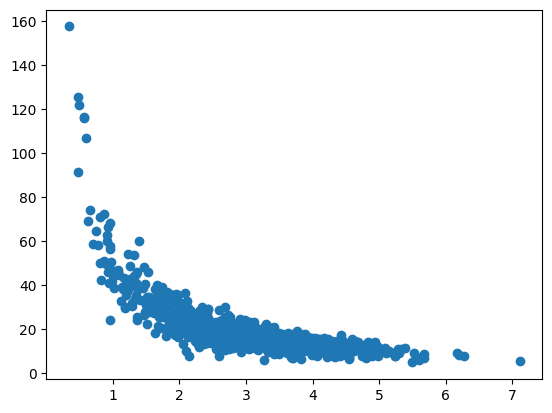

In [44]:
np.random.seed(2)
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds

plt.scatter(pageSpeeds, purchaseAmount)

In [46]:
x = np.array(pageSpeeds)
y = np.array(purchaseAmount)

p4 = np.poly1d (np.polyfit(x, y, 4))

<function matplotlib.pyplot.show(close=None, block=None)>

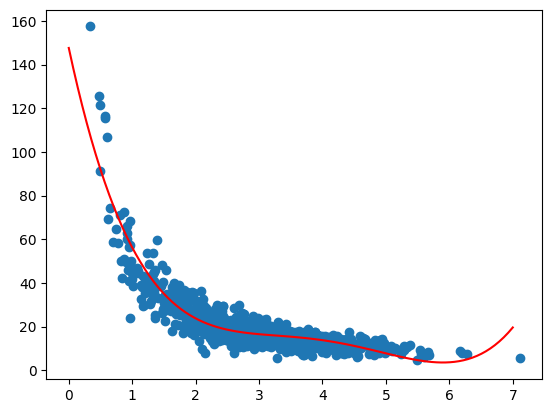

In [47]:
import matplotlib.pyplot as plt

xp = np.linspace(0, 7, 100)
plt.scatter(x, y)
plt.plot(xp, p4(xp), c='r')
plt.show

In [49]:
from sklearn.metrics import r2_score

r2 = r2_score(y, p4(x))
print(r2)

0.8293766396303073


### Multiple Regression 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
import pandas as pd 

df = pd.read_excel('http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls')

                     Mileage         Price
Mileage                                   
(0, 10000]       5588.629630  24096.714451
(10000, 20000]  15898.496183  21955.979607
(20000, 30000]  24114.407104  20278.606252
(30000, 40000]  33610.338710  19463.670267


<Axes: xlabel='Mileage'>

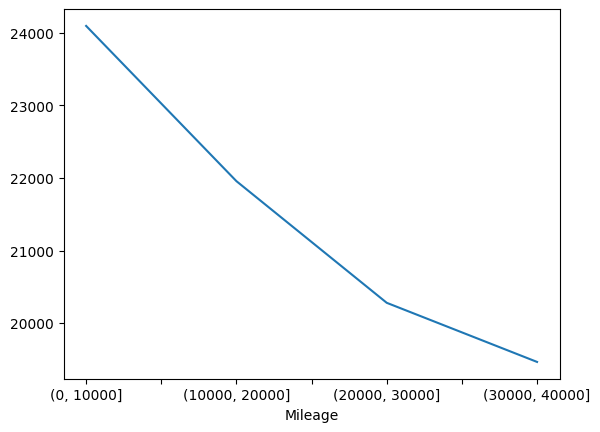

In [5]:
%matplotlib inline 
import numpy as np
df1=df[['Mileage','Price']]
bins = np.arange(0,50000,10000)
groups = df1.groupby(pd.cut(df1['Mileage'], bins)).mean()
print(groups.head())
groups['Price'].plot.line()

In [8]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler 
scale = StandardScaler()

X = df[['Mileage', 'Cylinder', 'Doors']]
y = df['Price']

X[['Mileage','Cylinder','Doors']] = scale.fit_transform(X[['Mileage', 'Cylinder', 'Doors']].values) #as_matrix()
print(X)
est = sm.OLS(y, X).fit()

est.summary()

      Mileage  Cylinder     Doors
0   -1.417485   0.52741  0.556279
1   -1.305902   0.52741  0.556279
2   -0.810128   0.52741  0.556279
3   -0.426058   0.52741  0.556279
4    0.000008   0.52741  0.556279
..        ...       ...       ...
799 -0.439853   0.52741  0.556279
800 -0.089966   0.52741  0.556279
801  0.079605   0.52741  0.556279
802  0.750446   0.52741  0.556279
803  1.932565   0.52741  0.556279

[804 rows x 3 columns]


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.064
Model:                            OLS   Adj. R-squared (uncentered):              0.060
Method:                 Least Squares   F-statistic:                              18.11
Date:                Mon, 13 Apr 2026   Prob (F-statistic):                    2.23e-11
Time:                        10:27:27   Log-Likelihood:                         -9207.1
No. Observations:                 804   AIC:                                  1.842e+04
Df Residuals:                     801   BIC:                                  1.843e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Mileage    -1272.3412    804.623     -1.581      0.114   -2851.759     307.077
Cylinder    5587.4472    804.509      6.945      0.000    4008.252    7166.642
Doors      -1404.5513    804.275     -1.746      0.081   -2983.288     174.185
==============================================================================
Omnibus:                      157.913   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              257.529
Skew:                           1.278   Prob(JB):                     1.20e-56
Kurtosis:                       4.074   Cond. No.                         1.03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
y.groupby(df.Doors).mean()

Doors
2    23807.135520
4    20580.670749
Name: Price, dtype: float64

In [10]:
scaled = scale.transform([[45000, 8, 4]])
print(scaled)
predicted = est.predict(scaled[0])
print(predicted)

[[3.07256589 1.96971667 0.55627894]]
[6315.01330583]


### Machine Learning with Python 

### Train/Test

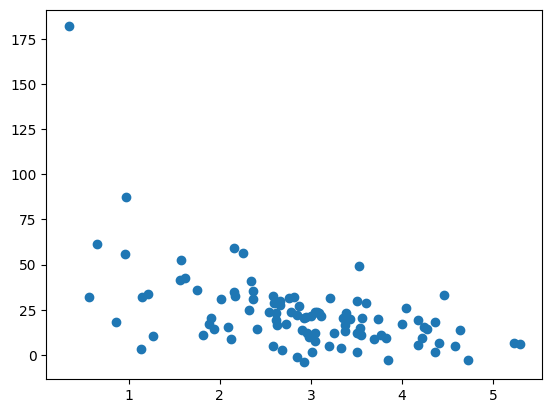

In [12]:
import numpy as np
import matplotlib.pyplot as plt 

np.random.seed(2) #distribuição de dados aleatórios 

pageSpeeds = np.random.normal(3.0, 1.0, 100) #Eixo y
purchaseAmount = np.random.normal(50.0, 30.0, 100) / pageSpeeds #Eixo x 

plt.scatter(pageSpeeds, purchaseAmount) #cria o gráfico com as informações

In [22]:
#Dividi os dados e pega 80 dos dados e reserva pra treinamento do Eixo X e Eixo Y
trainX = pageSpeeds[:80]
testX = pageSpeeds[80:]

trainY = purchaseAmount[:80]
testY = purchaseAmount[80:]

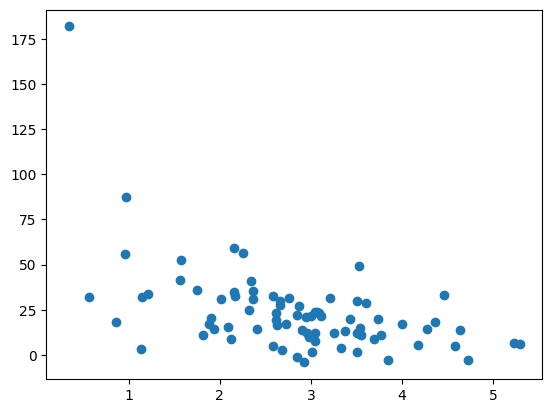

In [24]:
plt.scatter(trainX, trainY) #Imprime o gráfico

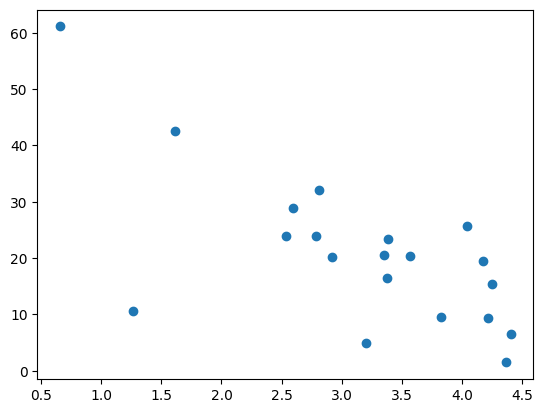

In [25]:
plt.scatter(testX, testY)

In [28]:
#ajuste de um polinômio de oitavo grau aos dados 
x = np.array(trainX) # array que contem os dados de treinamento X 
y = np.array(trainY) # array que contem os dados de treinamento Y

p4 = np.poly1d(np.polyfit(x, y, 8)) #utilizado para prever novos valores aos dados 

<function matplotlib.pyplot.show(close=None, block=None)>

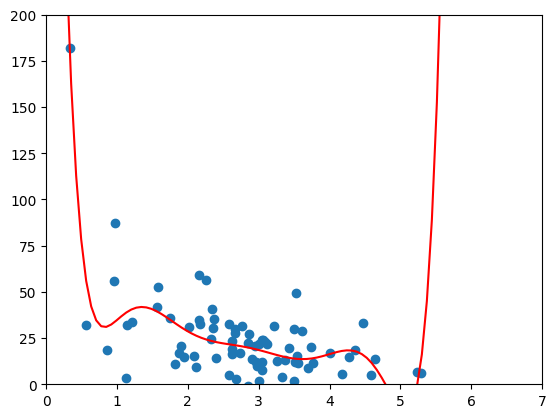

In [29]:
import matplotlib.pyplot as plt 

xp = np.linspace(0, 7, 100)
axes = plt.axes()
axes.set_xlim([0,7])
axes.set_ylim([0, 200])
plt.scatter(x, y)
plt.plot(xp, p4(xp), c='r')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

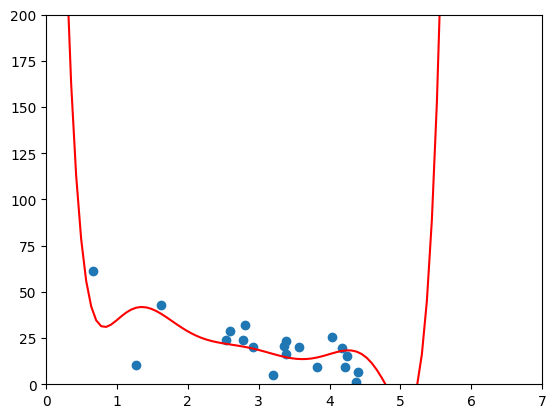

In [30]:
#essa versão sendo utilizado dados de teste 
testx = np.array(testX)
testy = np.array(testY)

axes = plt.axes()
axes.set_xlim([0,7])
axes.set_ylim([0, 200])
plt.scatter(testX, testY)
plt.plot(xp, p4(xp), c='r')
plt.show

In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(testy, p4(testx)) #mede o r2 dos dados de teste

print(r2) #mostra a pontuação ao quadrado 

0.3001816861144364


In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(np.array(trainY), p4(np.array(trainX))) #mede o r2 dos dados de treinamento

print(r2) #mostra a pontuação ao quadrado 

0.6427069514693098


### Naive Bayes(The easy way)

In [48]:
import os  #serve para manipular caminhos de diretorios e arquivos
import io  #lida com fluxos de arquivos
import numpy 
import pandas as pd  
from pandas import DataFrame  
from sklearn.feature_extraction.text import CountVectorizer  #transformar mensagens em valores numéricos
from sklearn.naive_bayes import MultinomialNB  #aprendizado de maquina para classificação


def readFiles(path):
    for root, dirnames, filenames in os.walk(path):  #caminha pelos diretorios especificados
        for filename in filenames: 
            path = os.path.join(root, filename)  #pega o caminho completo do arquivo

            inBody = False  #identificar se estamos na parte do corpo do e-mail
            lines = []  #lista para armazenar as linhas do corpo do e-mail
            f = io.open(path, 'r', encoding='latin1')  # Abre o arquivo 
            for line in f:
                if inBody:  # caso ja esteja na parte do corpo, adicionamos as linhas
                    lines.append(line)
                elif line == '\n':  # Uma linha em branco separa o cabecalho do corpo
                    inBody = True
            f.close()  # Fecha o arquivo
            message = '\n'.join(lines)  # Junta as linhas do corpo em uma unica string
            yield path, message  #retorna o caminho do arquivo e o conteudo do e-mail



def dataFrameFromDirectory(path, classification):
    rows = []  #lista para armazenar os dados de cada arquivo
    index = []  #lista para armazenar os nomes dos arquivos como indice
    for filename, message in readFiles(path):  # Usa a função anterior para ler arquivos
        rows.append({'message': message, 'class': classification})  # Adiciona uma linha com a mensagem e a classe
        index.append(filename)  # Adiciona o nome do arquivo ao indice anteriormente citado
        

    return DataFrame(rows, index=index)  # Retorna um DataFrame com os dados
    
data = pd.concat([
     dataFrameFromDirectory(r'C:\Users\marya\OneDrive\Área de Trabalho\emails\emails\spam', 'spam'),
     dataFrameFromDirectory(r'C:\Users\marya\OneDrive\Área de Trabalho\emails\emails\ham', 'ham')
], ignore_index=True)

In [49]:
data.head()

,message,class
0,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam
1,1) Fight The Risk of Cancer!\n\nhttp://www.adc...,spam
2,1) Fight The Risk of Cancer!\n\nhttp://www.adc...,spam
3,##############################################...,spam
4,I thought you might like these:\n\n1) Slim Dow...,spam


In [50]:
vectorizer = CountVectorizer()
counts = vectorizer.fit_transform(data['message'].values)

classifier = MultinomialNB()
targets = data['class'].values
classifier.fit(counts, targets)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [51]:
examples = ('Free Viagra now!!!', 'Hi Bob, how about a game of golf tomorrow?')
example_counts = vectorizer.transform(examples)
predictions = classifier.predict(example_counts)
print(predictions)

['spam' 'ham']


### K-menas Clustering Example 

In [58]:
def createClusteredData(N, k):
    random.seed(10)
    pointsPerCluster = float(N)/k
    X = []
    for i in range(k):
        incomeCentroid = random.uniform(20000.0, 200000.0)
        ageCentroid = random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
    X = np.array(X)
    return X

[4 4 4 4 4 4 4 4 4 2 4 4 2 2 4 2 2 4 4 4 3 3 3 0 0 3 3 3 3 3 3 0 0 3 0 3 3
 2 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 3 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 2 2 2 0 4 2 4 2 4 2 4 2 2 4 3 3 2 2 2 3]


<function matplotlib.pyplot.show(close=None, block=None)>

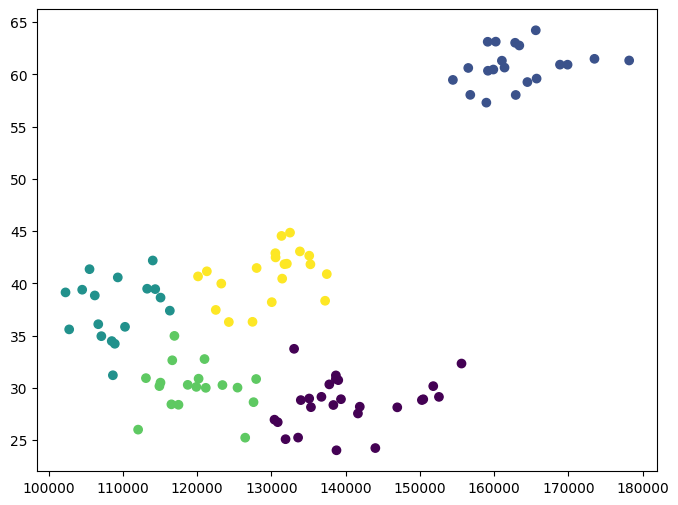

In [60]:
import random
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale

data = createClusteredData(100, 5)

model = KMeans(n_clusters=5)

model = model.fit(scale(data))

print(model.labels_)

plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model.labels_.astype(float))
plt.show

### Decison Trees

In [3]:
import numpy as np
import pandas as pd
from sklearn import tree

input_file = r"C:\Users\marya\OneDrive\Área de Trabalho\PastHires\PastHires.csv"
df = pd.read_csv(input_file, header = 0)

In [4]:
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


In [5]:
d = {'Y': 1, 'N': 0}
df['Hired'] = df['Hired'].map(d)
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)

d_edu = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d_edu)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


In [6]:
features = list(df.columns[:6])
features 

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [7]:
y = df['Hired']
X = df[features]
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X,y)

In [1]:
#from IPython.display import Image
#from io import StringIO #from sklearn.externals.six import StringIO
#import pydotplus #pydot

#dot_data = StringIO()
#tree.export_graphviz(clf, out_file=dot_data,
#                          feature_names=features)
#graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
#Image(graph.create_png())

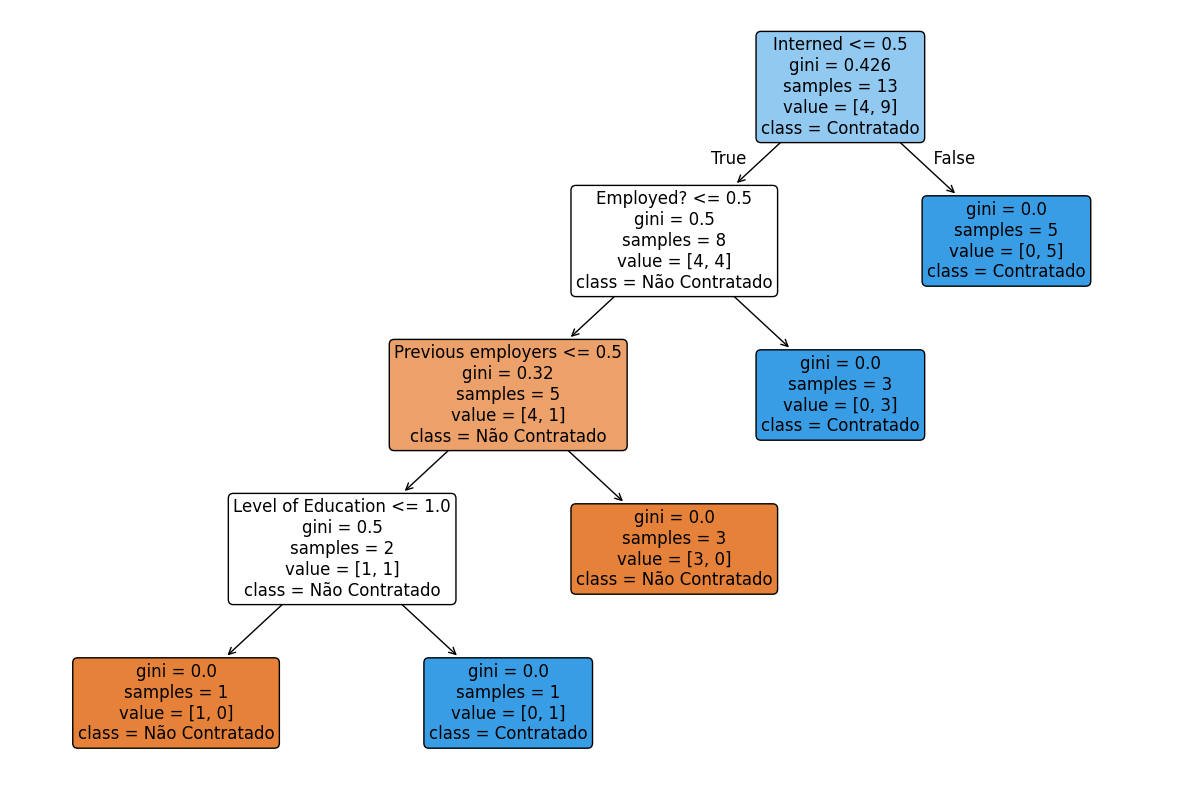

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15, 10))

#Desenha a árvore de decisão
tree.plot_tree(clf, 
               feature_names=features, 
               class_names=['Não Contratado', 'Contratado'], 
               filled=True, 
               rounded=True,
               fontsize=12)

#Exibe o gráfico
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(X,y)

print(clf.predict([[10, 1, 4, 0, 0, 0]]))
print(clf.predict([[10, 0, 4, 0, 0, 0]]))

[1]
[0]


C:\Users\marya\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\marya\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### XGBoost

In [2]:
from sklearn.datasets import load_iris 

iris = load_iris()

numSamples, numFeatures = iris.data.shape
print(numSamples)
print(numFeatures)
print(list(iris.target_names))

150
4
[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=0)

In [4]:
import xgboost as xgb

train = xgb.DMatrix(X_train, label=y_train)
test = xgb.DMatrix(X_test, label=y_test)

In [5]:
param = {
    'max_depth': 4,
    'eta': 0.3,
    'objective': 'multi:softmax',
    'num_class': 3}
epochs = 10

In [6]:
model = xgb.train(param, train, epochs)

In [7]:
predictions = model.predict(test)

In [8]:
print(predictions)

[2. 1. 0. 2. 0. 2. 0. 1. 1. 1. 2. 1. 1. 1. 1. 0. 1. 1. 0. 0. 2. 1. 0. 0.
 2. 0. 0. 1. 1. 0.]


In [9]:
from sklearn.metrics import accuracy_score

In [10]:
accuracy_score(y_test, predictions)

1.0

### Support Vector Machines 

In [11]:
import numpy as np

def createClusteredData(N, k):
    np.random.seed(1234)
    pointsPerCluster = float(N)/k
    X = []
    y = []
    for i in range(k):
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        ageCentroid = np.random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
            y.append(i)
    X = np.array(X)
    y = np.array(y)
    return X, y

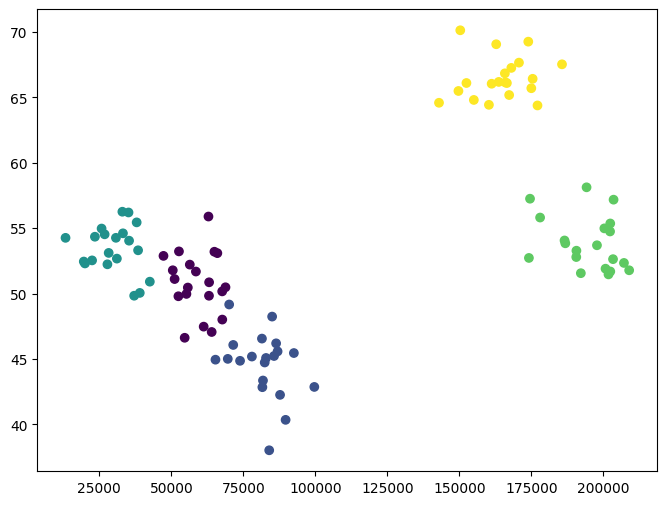

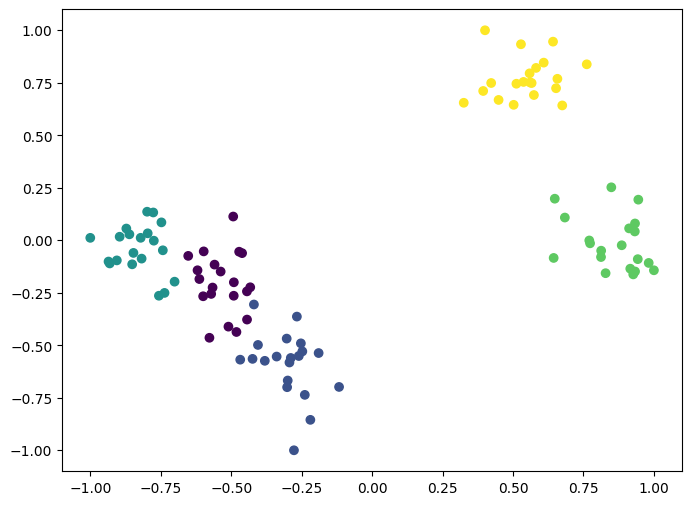

In [15]:
%matplotlib inline 
import numpy as np
from pylab import *
from sklearn.preprocessing import MinMaxScaler 

(X, y) = createClusteredData(100, 5)

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

scaling = MinMaxScaler(feature_range=(-1,1)).fit(X)
X = scaling.transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.astype(float))
plt.show()

In [16]:
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='linear', C=C).fit(X, y)

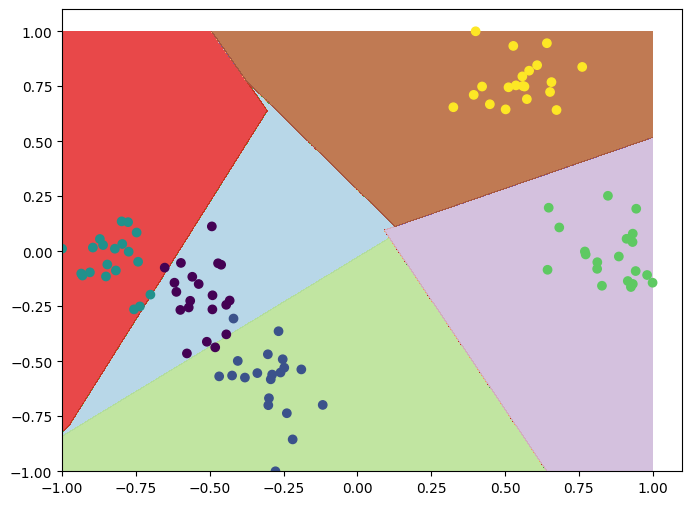

In [17]:
def plotPredictions(clf):
    # Create a dense grid of points to sample 
    xx, yy = np.meshgrid(np.arange(-1, 1, .001),
                     np.arange(-1, 1, .001))
    
    # Convert to Numpy arrays
    npx = xx.ravel()
    npy = yy.ravel()
    
    # Convert to a list of 2D (income, age) points
    samplePoints = np.c_[npx, npy]
    
    # Generate predicted labels (cluster numbers) for each point
    Z = clf.predict(samplePoints)

    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape) #Reshape results to match xx dimension
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # Draw the contour
    plt.scatter(X[:,0], X[:,1], c=y.astype(float)) # Draw the points
    plt.show()
    
plotPredictions(svc)

In [18]:
print(svc.predict(scaling.transform([[200000, 40]])))

[3]


In [19]:
print(svc.predict(scaling.transform([[50000, 65]])))

[2]
